# Multimodal Emotion Recognition v3 — DINOv2 + Temporal Attention + Gated Fusion

**Changes over v2 (visual branch only — audio branch is identical):**
- Visual backbone: `ConvNeXt V2 Base + SE` → **`DINOv2 ViT-B/14 + Temporal Self-Attention`**
- Frame count: 8 → **16** (ViT benefits from richer temporal context; reduces per-frame overfitting)
- Frame augmentation: independent per-frame → **consistent clip-level** (same random crop/flip/jitter applied to all T frames, preserving temporal coherence)
- `FaceOnlyDataset` now returns full clips `(T, C, H, W)` so FER pre-training also trains the temporal path
- `visual_dim` in GatedFusion: 1024 → **768** (DINOv2 ViT-B output dim)
- Phase 1b unfreeze: last 2 ConvNeXt stages → **last 4 ViT transformer blocks**

**Everything else is unchanged:** WavLM SER, audio preprocessing, RAVDESS dataset,
speaker-stratified split, GatedFusion architecture, MultimodalEmotionModel,
all training loops, evaluation, and gate analysis.

**Pipeline:** RAVDESS video → MediaPipe face crops (16 frames) + torchaudio audio  
→ Fine-tune SER (WavLM) → Fine-tune FER (DINOv2 + TemporalAttn) → Gated Fusion

**Labels:** `angry · happy · neutral · sad`


In [1]:
# Cell 1 — Install dependencies
import sys
print(sys.executable)
# Uncomment if needed:
# !pip install timm>=0.9.16 transformers torchaudio mediapipe --quiet
# DINOv2 is loaded via timm — no extra install needed beyond timm>=0.9


/home/teaching/anaconda3/envs/multimodal_clean/bin/python


In [2]:
# Cell 2 — Imports & Setup
import os, random, warnings, json
from pathlib import Path
from typing import Dict, Optional, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import autocast, GradScaler

import torchaudio
import torchaudio.transforms as T
import timm
from transformers import WavLMModel, WavLMConfig
from torchvision import transforms
import torchvision.transforms.functional as TF   # NEW: needed for consistent clip augmentation
from PIL import Image
import cv2
import mediapipe as mp

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

seed_everything(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/home/teaching/anaconda3/envs/multimodal_clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA RTX A5000
Memory : 25.4 GB


In [3]:
# Cell 3 — Config & Paths
VIDEO_ROOT = "/DATA/hackathon/data-video"
SAVE_DIR   = "/DATA/hackathon/multimodal_fusion_v3"
os.makedirs(SAVE_DIR, exist_ok=True)

EMOTION_LABELS = ["angry", "happy", "neutral", "sad"]
NUM_CLASSES    = len(EMOTION_LABELS)
LABEL2IDX      = {e: i for i, e in enumerate(EMOTION_LABELS)}

RAVDESS_EMOTION_MAP = {
    "01": "neutral",   # neutral
    "02": "neutral",   # calm → treated as neutral
    "03": "happy",
    "04": "sad",
    "05": "angry",
    # 06=fear, 07=disgust, 08=surprise — skipped (not in our 4-class set)
}

# ── Audio config (UNCHANGED from v2) ──────────────────────────────────────────
SAMPLE_RATE  = 16_000
MAX_DURATION = 3.5
MAX_SAMPLES  = int(SAMPLE_RATE * MAX_DURATION)  # 56,000

# ── SER pre-training (UNCHANGED) ──────────────────────────────────────────────
SER_BATCH_SIZE   = 16
SER_EPOCHS       = 20
SER_LR           = 5e-5
SER_WEIGHT_DECAY = 1e-4

# ── FER pre-training ──────────────────────────────────────────────────────────
# DINOv2 ViT-B/14: lower LR than ConvNeXt (ViTs are sensitive to large LRs)
FER_BATCH_SIZE   = 8    # reduced: 16 frames × 224² × float32 is heavier
FER_EPOCHS       = 20
FER_LR           = 5e-5   # lower than v2 (1e-4) — ViT head warm-up
FER_WEIGHT_DECAY = 1e-4

# ── NEW: visual config ─────────────────────────────────────────────────────────
NUM_FRAMES  = 16       # was 8 — more temporal context for ViT
VISUAL_DIM  = 768      # DINOv2 ViT-B/14 CLS output dim (was 1024 for ConvNeXt)
IMG_SIZE    = 224      # 224 / patch_size_14 = 16 patches/side — clean division

# ── Fusion training (mostly UNCHANGED) ────────────────────────────────────────
BATCH_SIZE   = 4       # 4 samples × 16 frames × 224² — keep GPU memory safe
EPOCHS       = 30
FUSION_LR    = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DROPOUT      = 0.3
PATIENCE     = 8
GRAD_CLIP    = 1.0
FUSION_DIM   = 512

# ── Phase 3 optional fine-tuning ──────────────────────────────────────────────
FINETUNE_BACKBONE_LR = 1e-6
FINETUNE_FUSION_LR   = 1e-4
FINETUNE_EPOCHS      = 10

print(f"Emotion labels : {EMOTION_LABELS}")
print(f"Num frames     : {NUM_FRAMES}  (↑ from 8)")
print(f"Visual dim     : {VISUAL_DIM}  (↓ from 1024, DINOv2 ViT-B output)")
print(f"Fusion dim     : {FUSION_DIM}")
print(f"Max audio len  : {MAX_DURATION}s = {MAX_SAMPLES} samples")
print(f"Save dir       : {SAVE_DIR}")


Emotion labels : ['angry', 'happy', 'neutral', 'sad']
Num frames     : 16  (↑ from 8)
Visual dim     : 768  (↓ from 1024, DINOv2 ViT-B output)
Fusion dim     : 512
Max audio len  : 3.5s = 56000 samples
Save dir       : /DATA/hackathon/multimodal_fusion_v3


## Audio Preprocessing (identical to v2 — no changes)

In [4]:
# Cell 4 — Audio Preprocessing  [UNCHANGED from v2]
def load_wav_from_file(path: str, sr: int = SAMPLE_RATE) -> np.ndarray:
    """Load and resample audio from any file (wav, mp4, etc)."""
    wav, orig_sr = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if orig_sr != sr:
        wav = torchaudio.transforms.Resample(orig_sr, sr)(wav)
    return wav.squeeze().numpy().astype(np.float32)

def vad_trim(wav: np.ndarray, sr: int = SAMPLE_RATE,
             thr: float = 0.01, frame_ms: int = 20) -> np.ndarray:
    """Energy-based VAD: trim low-energy leading/trailing frames."""
    hop = int(sr * frame_ms / 1000)
    n   = max(1, (len(wav) - hop) // hop + 1)
    rms = np.array([np.sqrt(np.mean(wav[i*hop : i*hop+hop]**2)) for i in range(n)])
    if rms.max() <= 1e-8:
        return wav
    voiced = np.where(rms >= thr * rms.max())[0]
    return wav[voiced[0]*hop : min(len(wav), voiced[-1]*hop + hop)] if len(voiced) else wav

def normalize_amplitude(wav: np.ndarray, peak: float = 0.95) -> np.ndarray:
    mx = np.abs(wav).max()
    return wav * (peak / mx) if mx > 1e-6 else wav

def segment_and_pad(wav: np.ndarray, length: int = MAX_SAMPLES) -> np.ndarray:
    if len(wav) >= length:
        start = (len(wav) - length) // 2
        return wav[start : start + length]
    return np.pad(wav, (0, length - len(wav)))

def preprocess_audio(path: str) -> Optional[np.ndarray]:
    """Full audio pipeline: load → VAD trim → normalize → pad."""
    try:
        wav = load_wav_from_file(path)
        wav = vad_trim(wav)
        wav = normalize_amplitude(wav)
        return segment_and_pad(wav)
    except Exception:
        return None

def audio_augment(wav: np.ndarray) -> np.ndarray:
    if random.random() < 0.5:
        wav = wav * 10 ** (random.uniform(-6, 6) / 20)
    if random.random() < 0.3:
        wav = wav + 0.005 * np.random.randn(len(wav)).astype(np.float32)
    if random.random() < 0.3:
        shift = int(random.uniform(-0.1, 0.1) * len(wav))
        wav = np.roll(wav, shift)
    return normalize_amplitude(wav)

print("Audio preprocessing ready.")


Audio preprocessing ready.


## Visual Preprocessing

**Changes from v2:**
- `NUM_FRAMES = 16` (was 8)
- New `ConsistentVideoTransform` replaces per-frame independent transforms.
  A single set of random parameters (crop box, flip coin, colour-jitter scalars)
  is sampled **once per clip** and applied identically to every frame.
  This is critical for temporal coherence — the temporal transformer must see
  natural expression dynamics, not augmentation artifacts masquerading as motion.


In [5]:
# Cell 5 — Face Extraction  [NUM_FRAMES updated to 16; MediaPipe unchanged]
mp_face_detection = mp.solutions.face_detection

# ── NEW: Consistent clip-level augmentation ────────────────────────────────────
# Key design principle: sample random parameters ONCE per clip, apply to ALL frames.
# Without this, independent per-frame jitter creates artificial "flicker" that the
# temporal transformer interprets as motion signal — leading to noisy gradients.

class ConsistentVideoTransform:
    """
    Applies the same random augmentation to every frame in a video clip.

    Train mode:
      - RandomResizedCrop  (scale 0.7-1.0, aspect 0.85-1.15) — same window for all frames
      - RandomHorizontalFlip                                   — same coin for all frames
      - ColorJitter (brightness, contrast, saturation)        — same factors for all frames
    Eval mode:
      - Resize to (IMG_SIZE, IMG_SIZE) — deterministic

    Parameters are sampled once per __call__ invocation (i.e., once per clip).
    """
    _MEAN = [0.485, 0.456, 0.406]
    _STD  = [0.229, 0.224, 0.225]

    def __init__(self, size: int = IMG_SIZE, train: bool = True):
        self.size  = size
        self.train = train

    def __call__(self, frames: list) -> torch.Tensor:
        """
        Args:
            frames: list of PIL.Image  (length T)
        Returns:
            torch.Tensor of shape (T, 3, H, W), float32, normalised
        """
        if self.train:
            # ── sample augmentation params once ──────────────────────────────
            # ResizedCrop params
            i, j, h, w = transforms.RandomResizedCrop.get_params(
                frames[0], scale=(0.70, 1.00), ratio=(0.85, 1.15))
            # Horizontal flip
            do_flip = random.random() < 0.5
            # Colour jitter (mild — we're on face crops, not ImageNet scenes)
            brightness_factor  = random.uniform(0.80, 1.20)
            contrast_factor    = random.uniform(0.80, 1.20)
            saturation_factor  = random.uniform(0.85, 1.15)

            processed = []
            for f in frames:
                f = TF.resized_crop(f, i, j, h, w, (self.size, self.size),
                                    interpolation=TF.InterpolationMode.BICUBIC)
                if do_flip:
                    f = TF.hflip(f)
                f = TF.adjust_brightness(f, brightness_factor)
                f = TF.adjust_contrast(f, contrast_factor)
                f = TF.adjust_saturation(f, saturation_factor)
                t = TF.to_tensor(f)
                t = TF.normalize(t, self._MEAN, self._STD)
                processed.append(t)
        else:
            processed = []
            for f in frames:
                f = TF.resize(f, (self.size, self.size),
                              interpolation=TF.InterpolationMode.BICUBIC)
                t = TF.to_tensor(f)
                t = TF.normalize(t, self._MEAN, self._STD)
                processed.append(t)

        return torch.stack(processed)  # (T, 3, H, W)


# Instantiate both variants for convenience
video_tf_train = ConsistentVideoTransform(size=IMG_SIZE, train=True)
video_tf_eval  = ConsistentVideoTransform(size=IMG_SIZE, train=False)


# ── Face extraction (unchanged except NUM_FRAMES) ────────────────────────────
def extract_faces_from_video(video_path: str,
                              num_frames: int = NUM_FRAMES) -> Optional[list]:
    """
    Extract `num_frames` face crops from a video using MediaPipe.
    Frames are sampled uniformly from the 10%-90% portion of the video
    to avoid title/fade frames.
    Pads by repeating the last valid face if fewer than num_frames//2 detected.

    No data-leakage risk: operates on a single video in isolation.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < num_frames:
        cap.release()
        return None

    frame_positions = np.linspace(0.1, 0.9, num_frames)
    faces = []

    with mp_face_detection.FaceDetection(
            model_selection=1, min_detection_confidence=0.3) as fd:
        for pos in frame_positions:
            cap.set(cv2.CAP_PROP_POS_FRAMES,
                    min(int(total * pos), total - 1))
            ret, frame = cap.read()
            if not ret:
                continue

            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results   = fd.process(image_rgb)

            if results.detections:
                bbox = results.detections[0].location_data.relative_bounding_box
                ih, iw, _ = frame.shape
                x  = int(bbox.xmin * iw)
                y  = int(bbox.ymin * ih)
                w  = int(bbox.width  * iw)
                h  = int(bbox.height * ih)
                x1, y1 = max(0, x - 20), max(0, y - 20)
                x2, y2 = min(iw, x + w + 20), min(ih, y + h + 20)
                faces.append(Image.fromarray(image_rgb).crop((x1, y1, x2, y2)))

    cap.release()

    # Need at least half the frames to be valid
    if len(faces) >= num_frames // 2:
        while len(faces) < num_frames:
            faces.append(faces[-1])   # pad by repeating last valid face
        return faces[:num_frames]
    return None


print(f"Face extraction ready  (num_frames={NUM_FRAMES}, img_size={IMG_SIZE}x{IMG_SIZE}).")
print("ConsistentVideoTransform defined  (train + eval variants).")


Face extraction ready  (num_frames=16, img_size=224x224).
ConsistentVideoTransform defined  (train + eval variants).


In [6]:
# Quick sanity-check on first video
vf = sorted(Path(VIDEO_ROOT).rglob("*.mp4"))[0]
faces = extract_faces_from_video(str(vf))
print(f"Got {len(faces)} face crops" if faces else "FAILED — check VIDEO_ROOT")
if faces:
    clip_train = video_tf_train(faces)
    clip_eval  = video_tf_eval(faces)
    print(f"Train clip tensor : {clip_train.shape}  dtype={clip_train.dtype}")
    print(f"Eval  clip tensor : {clip_eval.shape}")
    # Verify all frames got the SAME crop by checking corner pixels match
    # (they will differ by colour-jitter only, not by spatial shift)
    print(f"Frame 0 spatial max: {clip_eval[0].max():.4f} | Frame 7: {clip_eval[7].max():.4f}")


I0000 00:00:1776514665.282064 3466672 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776514665.360316 3466821 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.144.03), renderer: NVIDIA RTX A5000/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Got 16 face crops
Train clip tensor : torch.Size([16, 3, 224, 224])  dtype=torch.float32
Eval  clip tensor : torch.Size([16, 3, 224, 224])
Frame 0 spatial max: 2.6400 | Frame 7: 2.6400


## Dataset Builder (unchanged from v2 — NUM_FRAMES change propagates through config)

In [7]:
# Cell 6 — Dataset Builder  [UNCHANGED logic; NUM_FRAMES now 16 via config]
def parse_filename(fname: str) -> Optional[Dict]:
    parts = Path(fname).stem.split("-")
    if len(parts) != 7:
        return None
    return {
        "modality"    : parts[0],
        "channel"     : parts[1],
        "emotion_code": parts[2],
        "intensity"   : parts[3],
        "statement"   : parts[4],
        "repetition"  : parts[5],
        "actor"       : parts[6],
    }


def build_dataset(video_root: str) -> pd.DataFrame:
    """
    Scan RAVDESS video directory.
    Audio is extracted directly from each video file (no cross-file path risk).
    Returns DataFrame with pre-cached audio arrays and lists of 16 face PIL images.

    Data-leakage note: preprocessing is per-sample and stateless (uses ImageNet
    normalisation constants, not dataset statistics). No global normalisation is
    computed here. The speaker-stratified split in Cell 7 ensures no actor appears
    in more than one partition.
    """
    records = []
    skipped = {"modality": 0, "channel": 0, "emotion": 0, "face": 0, "audio": 0}

    video_files = sorted(Path(video_root).rglob("*.mp4"))
    print(f"Found {len(video_files)} .mp4 files in {video_root}")

    for vf in tqdm(video_files, desc="Building dataset"):
        info = parse_filename(vf.name)
        if info is None:
            continue

        # Only full-AV speech (modality=01, channel=01)
        if info["modality"] != "01":
            skipped["modality"] += 1; continue
        if info["channel"] != "01":
            skipped["channel"] += 1; continue

        emotion = RAVDESS_EMOTION_MAP.get(info["emotion_code"])
        if emotion is None:
            skipped["emotion"] += 1; continue

        # Extract 16 face crops
        faces = extract_faces_from_video(str(vf))
        if faces is None:
            skipped["face"] += 1; continue

        # Extract audio directly from the video file
        audio = preprocess_audio(str(vf))
        if audio is None:
            skipped["audio"] += 1; continue

        records.append({
            "video_path" : str(vf),
            "actor"      : int(info["actor"]),
            "emotion"    : emotion,
            "label"      : LABEL2IDX[emotion],
            "audio_cache": audio,
            "face_cache" : faces,   # list of 16 PIL images
        })

    df = pd.DataFrame(records)
    print(f"\nPaired samples : {len(df)}")
    print(f"Skipped        : {skipped}")
    print(f"\nEmotion distribution:")
    print(df["emotion"].value_counts().to_string())
    return df


df_all = build_dataset(VIDEO_ROOT)


Found 2880 .mp4 files in /DATA/hackathon/data-video


Building dataset:   0%|          | 0/2880 [00:00<?, ?it/s]I0000 00:00:1776514666.063304 3466672 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776514666.133074 3466924 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.144.03), renderer: NVIDIA RTX A5000/PCIe/SSE2
Building dataset:   0%|          | 1/2880 [00:00<32:17,  1.49it/s]I0000 00:00:1776514666.736184 3466672 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776514666.826584 3466980 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.144.03), renderer: NVIDIA RTX A5000/PCIe/SSE2
Building dataset:   0%|          | 2/2880 [00:01<32:22,  1.48it/s]I0000 00:00:1776514667.415268 3466672 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776514667.506565 3467036 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 550.144.03), renderer: NVIDIA RTX A5000/PCIe/SSE2
Building dataset:   0%|          | 3/2880 [00:02


Paired samples : 864
Skipped        : {'modality': 1440, 'channel': 0, 'emotion': 576, 'face': 0, 'audio': 0}

Emotion distribution:
emotion
neutral    288
happy      192
sad        192
angry      192


In [8]:
# Cell 7 — Speaker-Stratified Split  [UNCHANGED from v2 — no data leakage]
#
# Data-leakage note: split is performed at the ACTOR level, not sample level.
# Every clip from a given actor lands in exactly one partition.
# This prevents the model from memorising actor-specific speech patterns /
# facial geometry and reporting inflated test metrics.

def speaker_stratified_split(df: pd.DataFrame,
                              train_frac=0.7, val_frac=0.1, seed=42):
    rng    = np.random.default_rng(seed)
    actors = df["actor"].unique().copy()
    rng.shuffle(actors)

    n_tr = max(1, int(len(actors) * train_frac))
    n_va = max(1, int(len(actors) * val_frac))

    train_actors = set(actors[:n_tr])
    val_actors   = set(actors[n_tr : n_tr + n_va])
    test_actors  = set(actors[n_tr + n_va:])

    tr = df[df["actor"].isin(train_actors)].reset_index(drop=True)
    va = df[df["actor"].isin(val_actors)].reset_index(drop=True)
    te = df[df["actor"].isin(test_actors)].reset_index(drop=True)

    print(f"Split by speakers — Train: {len(tr)} | Val: {len(va)} | Test: {len(te)}")
    print(f"  Train actors : {sorted(train_actors)}")
    print(f"  Val   actors : {sorted(val_actors)}")
    print(f"  Test  actors : {sorted(test_actors)}")

    # Leakage sanity-check: no actor should appear in more than one split
    assert not (train_actors & val_actors), "LEAKAGE: actor overlap train/val"
    assert not (train_actors & test_actors), "LEAKAGE: actor overlap train/test"
    assert not (val_actors   & test_actors), "LEAKAGE: actor overlap val/test"
    print("  ✓ No actor overlap across splits.")
    return tr, va, te


train_df, val_df, test_df = speaker_stratified_split(df_all)


Split by speakers — Train: 576 | Val: 72 | Test: 216
  Train actors : [1, 4, 6, 7, 8, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21, 24]
  Val   actors : [15, 23]
  Test  actors : [2, 3, 5, 9, 14, 22]
  ✓ No actor overlap across splits.


## Dataset Classes

**Key change vs v2:**  
`FaceOnlyDataset` now returns **full clips `(T, C, H, W)`** using `ConsistentVideoTransform`,
not a single randomly-selected frame. This is necessary because the new `FERModel`
has a temporal self-attention module that must be trained end-to-end on clip inputs —
training on single frames would leave the temporal path completely untrained.

`MultimodalDataset` similarly uses `ConsistentVideoTransform` instead of stacking
independently transformed frames.

`AudioOnlyDataset` is **unchanged**.


In [9]:
# Cell 8 — Dataset Classes  [FaceOnlyDataset and MultimodalDataset updated]

class AudioOnlyDataset(Dataset):
    """For SER pre-training phase.  [UNCHANGED from v2]"""
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = row["audio_cache"].copy()
        if self.augment:
            wav = audio_augment(wav)
        return torch.from_numpy(segment_and_pad(wav)), int(row["label"])


class FaceOnlyDataset(Dataset):
    """
    For FER pre-training phase.

    v2: returned a single frame (C, H, W)
    v3: returns the full clip (T, C, H, W) so the temporal self-attention
        path is trained end-to-end during Phase 1.

    ConsistentVideoTransform is used to ensure temporal coherence:
    the same random crop/flip/colour params are applied to all T frames.
    """
    def __init__(self, df: pd.DataFrame, video_tf=None, augment: bool = False):
        self.df       = df.reset_index(drop=True)
        self.video_tf = video_tf if video_tf is not None else video_tf_eval
        self.augment  = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        faces = row["face_cache"]          # list of T=16 PIL images
        clip  = self.video_tf(faces)       # (T, 3, H, W)
        return clip, int(row["label"])


class MultimodalDataset(Dataset):
    """
    For fusion training phase.

    Audio path: unchanged.
    Visual path: ConsistentVideoTransform → (T, 3, H, W) clip tensor.
    """
    def __init__(self, df: pd.DataFrame, video_tf=None, augment: bool = False):
        self.df       = df.reset_index(drop=True)
        self.video_tf = video_tf if video_tf is not None else video_tf_eval
        self.augment  = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        wav   = row["audio_cache"].copy()
        if self.augment:
            wav = audio_augment(wav)
        faces = row["face_cache"]          # list of T=16 PIL images
        clip  = self.video_tf(faces)       # (T, 3, H, W)
        return torch.from_numpy(segment_and_pad(wav)), clip, int(row["label"])


def make_loaders(train, val, test, dataset_class, kwargs_train, kwargs_eval,
                 batch_size=16, num_workers=4):
    tr = DataLoader(dataset_class(train, **kwargs_train),
                    batch_size=batch_size, shuffle=True,
                    num_workers=num_workers, pin_memory=True, drop_last=True)
    va = DataLoader(dataset_class(val,  **kwargs_eval),
                    batch_size=batch_size, num_workers=num_workers, pin_memory=True)
    te = DataLoader(dataset_class(test, **kwargs_eval),
                    batch_size=batch_size, num_workers=num_workers, pin_memory=True)
    return tr, va, te


print("Dataset classes defined.")


Dataset classes defined.


In [10]:
# Dataset sanity-check
ds_mm = MultimodalDataset(train_df, video_tf=video_tf_train, augment=True)
wav_s, clip_s, lbl_s = ds_mm[0]
print(f"wav  : {wav_s.shape}         — expected (56000,)")
print(f"clip : {clip_s.shape}  — expected ({NUM_FRAMES}, 3, {IMG_SIZE}, {IMG_SIZE})")
print(f"label: {lbl_s}  ({EMOTION_LABELS[lbl_s]})")

ds_fer = FaceOnlyDataset(train_df, video_tf=video_tf_train, augment=True)
clip_fer, lbl_fer = ds_fer[0]
print(f"FER clip : {clip_fer.shape}")


wav  : torch.Size([56000])         — expected (56000,)
clip : torch.Size([16, 3, 224, 224])  — expected (16, 3, 224, 224)
label: 2  (neutral)
FER clip : torch.Size([16, 3, 224, 224])


## Phase 0 — SER Pre-Training (audio-only)  [IDENTICAL to v2]

In [11]:
# Cell 9 — SER Model Architecture  [UNCHANGED from v2]

class SpeakerNorm(nn.Module):
    def __init__(self, dim: int = 768, eps: float = 1e-6):
        super().__init__()
        self.norm = nn.InstanceNorm1d(dim, eps=eps, affine=True)
    def forward(self, x):
        return self.norm(x.transpose(1, 2)).transpose(1, 2)


class WeightedLayerFusion(nn.Module):
    def __init__(self, k: int = 12):
        super().__init__()
        self.k      = k
        self.weight = nn.Parameter(torch.zeros(k))
    def forward(self, hidden_states):
        chosen  = hidden_states[-self.k:]
        w       = torch.softmax(self.weight, dim=0)
        stacked = torch.stack(chosen, dim=0)
        return (stacked * w[:, None, None, None]).sum(0)


class AttentionPooling(nn.Module):
    def __init__(self, hidden_size: int = 768, n_heads: int = 4):
        super().__init__()
        self.attn  = nn.MultiheadAttention(hidden_size, n_heads,
                                            batch_first=True, dropout=0.1)
        self.query = nn.Parameter(torch.randn(1, 1, hidden_size) * 0.02)
    def forward(self, x):
        q = self.query.expand(x.size(0), -1, -1)
        out, _ = self.attn(q, x, x)
        return out.squeeze(1)


class SERModel(nn.Module):
    """
    Speech Emotion Recognition model.
    WavLM-Base+ → Weighted layer fusion → SpeakerNorm → AttentionPool → Classifier
    [UNCHANGED from v2]
    """
    def __init__(self, n_class: int = 4,
                 backbone_name: str = "microsoft/wavlm-base-plus"):
        super().__init__()
        cfg = WavLMConfig.from_pretrained(backbone_name, output_hidden_states=True)
        self.backbone   = WavLMModel.from_pretrained(backbone_name, config=cfg,
                                                      use_safetensors=True)
        self.fuse       = WeightedLayerFusion(k=12)
        self.spk_norm   = SpeakerNorm(dim=768)
        self.attn_pool  = AttentionPooling(768, 4)
        self.layer_norm = nn.LayerNorm(768)
        self.emotion_head = nn.Sequential(
            nn.Linear(768, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_class),
        )
        for p in self.backbone.parameters():
            p.requires_grad = False

    def _embed(self, wav: torch.Tensor) -> torch.Tensor:
        out = self.backbone(wav, output_hidden_states=True)
        h   = self.fuse(out.hidden_states)
        h   = self.spk_norm(h)
        z   = self.attn_pool(h)
        return self.layer_norm(z)

    def forward(self, wav: torch.Tensor) -> torch.Tensor:
        return self.emotion_head(self._embed(wav))

    def extract_features(self, wav: torch.Tensor) -> torch.Tensor:
        return self._embed(wav)


ser_model = SERModel(n_class=NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in ser_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ser_model.parameters())
print(f"SER model — trainable: {trainable:,} / total: {total:,}")


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 6288.05it/s]


SER model — trainable: 2,564,624 / total: 96,946,560


In [12]:
# Cell 10 — SER Phase 0a: Train head only  [UNCHANGED from v2]

ser_train_loader, ser_val_loader, ser_test_loader = make_loaders(
    train_df, val_df, test_df,
    AudioOnlyDataset,
    kwargs_train={"augment": True},
    kwargs_eval ={"augment": False},
    batch_size=SER_BATCH_SIZE
)

def train_epoch_1d(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for wav, labels in tqdm(loader, desc="SER train", leave=False):
        wav, labels = wav.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits = model(wav)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_1d(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for wav, labels in tqdm(loader, desc="SER eval", leave=False):
        wav, labels = wav.to(DEVICE), labels.to(DEVICE)
        with autocast():
            logits = model(wav)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    p, l = np.array(all_preds), np.array(all_labels)
    return {
        "loss": total_loss / len(l),
        "acc" : accuracy_score(l, p),
        "uar" : recall_score(l, p, average="macro"),
        "f1"  : f1_score(l, p, average="macro"),
    }

criterion_ser = nn.CrossEntropyLoss(label_smoothing=0.1)
opt_ser       = AdamW([p for p in ser_model.parameters() if p.requires_grad],
                       lr=SER_LR, weight_decay=SER_WEIGHT_DECAY)
sch_ser       = CosineAnnealingWarmRestarts(opt_ser, T_0=10, T_mult=1, eta_min=1e-6)
scaler_ser    = GradScaler()
SER_CKPT      = os.path.join(SAVE_DIR, "ser_pretrained.pt")

best_uar, patience_ctr = 0.0, 0
print("SER Phase 0a — training head (backbone frozen)")
for epoch in range(1, SER_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch_1d(ser_model, ser_train_loader, opt_ser, criterion_ser, scaler_ser)
    val_m           = eval_1d(ser_model, ser_val_loader, criterion_ser)
    sch_ser.step()
    print(f"Ep {epoch:02d}/{SER_EPOCHS}  train_acc={tr_acc:.4f} | val_acc={val_m['acc']:.4f}  val_uar={val_m['uar']:.4f}")
    if val_m["uar"] > best_uar:
        best_uar, patience_ctr = val_m["uar"], 0
        torch.save(ser_model.state_dict(), SER_CKPT)
        print(f"  ✓ Best UAR={best_uar:.4f} saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE: print("Early stop (SER 0a)."); break

print(f"Phase 0a done. Best UAR={best_uar:.4f}")


SER Phase 0a — training head (backbone frozen)


Ep 01/20  train_acc=0.3108 | val_acc=0.3333  val_uar=0.2500
  ✓ Best UAR=0.2500 saved.


Ep 02/20  train_acc=0.2969 | val_acc=0.3333  val_uar=0.2500


Ep 03/20  train_acc=0.4028 | val_acc=0.4306  val_uar=0.3594
  ✓ Best UAR=0.3594 saved.


Ep 04/20  train_acc=0.4601 | val_acc=0.4028  val_uar=0.3281


...

Ep 16/20  train_acc=0.8472 | val_acc=0.8889  val_uar=0.8802
  ✓ Best UAR=0.8802 saved.


Ep 17/20  train_acc=0.8681 | val_acc=0.8750  val_uar=0.8646


Ep 18/20  train_acc=0.8976 | val_acc=0.8750  val_uar=0.8594


Ep 19/20  train_acc=0.8767 | val_acc=0.8611  val_uar=0.8438


Ep 20/20  train_acc=0.8924 | val_acc=0.9028  val_uar=0.8906
  ✓ Best UAR=0.8906 saved.
Phase 0a done. Best UAR=0.8906


In [13]:
# Cell 11 — SER Phase 0b: Unfreeze top WavLM layers  [UNCHANGED from v2]

ser_model.load_state_dict(torch.load(SER_CKPT, map_location=DEVICE))

for layer in list(ser_model.backbone.encoder.layers)[-4:]:
    for p in layer.parameters():
        p.requires_grad = True

unf = sum(p.numel() for p in ser_model.parameters() if p.requires_grad)
print(f"SER Phase 0b — trainable after unfreeze: {unf:,}")

opt_ser2 = AdamW([
    {"params": [p for n, p in ser_model.named_parameters()
                if p.requires_grad and "backbone" in n], "lr": 1e-5},
    {"params": [p for n, p in ser_model.named_parameters()
                if p.requires_grad and "backbone" not in n], "lr": 2e-4},
], weight_decay=SER_WEIGHT_DECAY)

sch_ser2    = CosineAnnealingWarmRestarts(opt_ser2, T_0=5, eta_min=1e-7)
scaler_ser2 = GradScaler()
SER_CKPT_FT = os.path.join(SAVE_DIR, "ser_finetuned.pt")

best_uar2, patience_ctr2 = best_uar, 0
for epoch in range(1, 11):
    tr_loss, tr_acc = train_epoch_1d(ser_model, ser_train_loader, opt_ser2, criterion_ser, scaler_ser2)
    val_m           = eval_1d(ser_model, ser_val_loader, criterion_ser)
    sch_ser2.step()
    print(f"0b Ep {epoch:02d}/10  train_acc={tr_acc:.4f} | val_acc={val_m['acc']:.4f}  val_uar={val_m['uar']:.4f}")
    if val_m["uar"] > best_uar2:
        best_uar2, patience_ctr2 = val_m["uar"], 0
        torch.save(ser_model.state_dict(), SER_CKPT_FT)
        print(f"  ✓ Best UAR={best_uar2:.4f}")
    else:
        patience_ctr2 += 1
        if patience_ctr2 >= 5: print("Early stop (SER 0b)."); break

best_ser_ckpt = SER_CKPT_FT if os.path.exists(SER_CKPT_FT) else SER_CKPT
ser_model.load_state_dict(torch.load(best_ser_ckpt, map_location=DEVICE))
ser_model.eval()
for p in ser_model.parameters(): p.requires_grad = False

test_ser = eval_1d(ser_model, ser_test_loader, criterion_ser)
print(f"\nSER Test — Acc={test_ser['acc']:.4f}  UAR={test_ser['uar']:.4f}  F1={test_ser['f1']:.4f}")
print("SER backbone frozen for fusion stage.")


SER Phase 0b — trainable after unfreeze: 30,918,240


0b Ep 01/10  train_acc=0.7083 | val_acc=0.8056  val_uar=0.7812


0b Ep 02/10  train_acc=0.8490 | val_acc=0.7778  val_uar=0.7969


0b Ep 03/10  train_acc=0.9045 | val_acc=0.8889  val_uar=0.8854


0b Ep 04/10  train_acc=0.9080 | val_acc=0.8056  val_uar=0.8177


0b Ep 05/10  train_acc=0.9323 | val_acc=0.8750  val_uar=0.8698
Early stop (SER 0b).



SER Test — Acc=0.8009  UAR=0.7951  F1=0.7928
SER backbone frozen for fusion stage.


## Phase 1 — FER Pre-Training (face-only)

### Architecture: DINOv2 ViT-B/14 + Temporal Self-Attention

**Why DINOv2 over ConvNeXt V2?**

| Property | ConvNeXt V2 Base | DINOv2 ViT-B/14 |
|---|---|---|
| Pretraining | Supervised IN-22k | Self-supervised LVD-142M (142M diverse images) |
| Inductive bias | Strong (conv locality) | Weak (global self-attention) |
| Facial feature quality | Good | Exceptional — ViTs trained with DINO develop emergent segmentation of facial parts |
| Temporal modelling | External mean-pool | Native sequence format — each frame = token sequence |
| Overfitting risk on small data | Low | Higher — mitigated by frozen backbone + temporal dropout |

**Why Temporal Self-Attention?**

The previous pipeline mean-pooled `N` frame features — a bag-of-frames approach that discards
all information about *how* expressions evolve. Temporal Self-Attention treats the `T` CLS tokens
as a sequence, letting the model learn that "neutral → slight raise → smile" = happy rather than
treating each frame independently. This is the primary reason we expect visual to surpass audio.

**Architecture flow:**
```
Input (B, T, 3, 224, 224)
  → reshape (B*T, 3, 224, 224)
  → DINOv2 ViT-B/14  [frozen initially]
  → CLS tokens: (B*T, 768)
  → reshape (B, T, 768)
  → positional encoding (learnable, T positions)
  → Temporal Self-Attention (2 transformer layers, 8 heads)
  → mean pool over T  →  (B, 768)
  → LayerNorm + Dropout
  → head: Linear(768→256) → GELU → Dropout → Linear(256→4)
```

**Latency budget (3-second Streamlit demo):**
- Frame extraction: ~0.3s (MediaPipe on 16 frames)  
- DINOv2 forward (B=1×16): ~0.15s on GPU  
- Temporal attention + head: ~0.01s  
- **Total visual path: ~0.5s** — well within 3s budget

**Data-leakage note:** DINOv2 is pretrained on a general-purpose corpus (LVD-142M) with no overlap
with RAVDESS. Temporal positional encodings are learned from scratch on training actors only.
The frozen backbone itself carries no RAVDESS-specific information.


In [14]:
# Cell 12 — FER Model Architecture  [COMPLETELY REPLACED: DINOv2 + Temporal Attention]

class TemporalSelfAttention(nn.Module):
    """
    Lightweight 2-layer transformer encoder for modelling expression dynamics
    across DINOv2 frame CLS tokens.

    Design choices:
    - 2 layers: sufficient for 16 frames on a ~1k-sample dataset; deeper = overfit
    - 8 heads on dim=768: matches DINOv2 ViT-B internal attention width
    - Pre-LN (layer norm before attention): more stable for small datasets
    - Learnable positional encoding: lets model learn which frames are most
      informative (e.g., peak expression frames carry more weight than onset)
    - dropout=0.1 on attention weights: regularises temporal paths

    Input : (B, T, 768)
    Output: (B, T, 768)  — caller mean-pools over T
    """
    def __init__(self, dim: int = 768, n_heads: int = 8,
                 n_layers: int = 2, dropout: float = 0.1,
                 n_frames: int = NUM_FRAMES):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.zeros(1, n_frames, dim))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=n_heads,
            dim_feedforward=dim * 2,   # compact FFN — 2× not 4×
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,           # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm    = nn.LayerNorm(dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, T, dim) → (B, T, dim)"""
        x = x + self.pos_emb[:, :x.size(1), :]
        x = self.encoder(x)
        return self.norm(x)


class FERModel(nn.Module):
    """
    Facial Emotion Recognition model  [v3: DINOv2 ViT-B/14 + Temporal Self-Attention]

    Replaces v2's ConvNeXt V2 Base + SE block + AdaptiveAvgPool.

    extract_features(x) accepts:
      - 5-D input (B, T, C, H, W) — clip (used by fusion)
      - 4-D input (B, C, H, W)    — single frame (edge case; repeats to T=1)
    Returns (B, VISUAL_DIM=768) for downstream gated fusion.
    """
    def __init__(self, n_class: int = 4, n_frames: int = NUM_FRAMES,
                 embed_dim: int = VISUAL_DIM, dropout: float = 0.4):
        super().__init__()

        # ── DINOv2 ViT-B/14  ─────────────────────────────────────────────────
        # timm identifier: vit_base_patch14_dinov2.lvd142m
        # img_size=224 → 16×16 = 256 spatial tokens + 1 CLS = 257 total
        # num_classes=0 → returns CLS token directly (shape: B, 768)
        self.backbone = timm.create_model(
            "vit_base_patch14_dinov2.lvd142m",
            pretrained=True,
            num_classes=0,        # no classification head — we use CLS token
            img_size=IMG_SIZE,    # 224
        )
        # Freeze all backbone params initially; Phase 1b will unfreeze last 4 blocks
        for p in self.backbone.parameters():
            p.requires_grad = False

        # ── Temporal Self-Attention  ──────────────────────────────────────────
        self.temporal_attn = TemporalSelfAttention(
            dim=embed_dim, n_heads=8, n_layers=2,
            dropout=0.1, n_frames=n_frames
        )

        # ── Classification head  ──────────────────────────────────────────────
        self.head_norm = nn.LayerNorm(embed_dim)
        self.dropout   = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_class),
        )

        self.embed_dim = embed_dim
        self.n_frames  = n_frames

    def _extract_clip_features(self, clip: torch.Tensor) -> torch.Tensor:
        """
        clip: (B, T, C, H, W)
        Returns: (B, embed_dim)

        Steps:
          1. Flatten to (B*T, C, H, W) for efficient batched DINOv2 forward
          2. Extract CLS token → (B*T, 768)
          3. Reshape to (B, T, 768)
          4. Temporal self-attention → (B, T, 768)
          5. Mean pool over T → (B, 768)
        """
        B, T, C, H, W = clip.shape
        # ── step 1-2: batched DINOv2 forward ──────────────────────────────
        clip_flat = clip.view(B * T, C, H, W)        # (B*T, C, H, W)
        cls_flat  = self.backbone(clip_flat)           # (B*T, 768)
        # ── step 3: restore temporal axis ─────────────────────────────────
        cls_seq   = cls_flat.view(B, T, self.embed_dim)  # (B, T, 768)
        # ── step 4: temporal self-attention ───────────────────────────────
        ctx       = self.temporal_attn(cls_seq)           # (B, T, 768)
        # ── step 5: mean pool ─────────────────────────────────────────────
        z         = ctx.mean(dim=1)                        # (B, 768)
        return self.head_norm(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, T, C, H, W) — returns logits (B, n_class)"""
        if x.dim() == 4:                   # single-frame fallback
            x = x.unsqueeze(1)
        z = self._extract_clip_features(x)
        return self.head(self.dropout(z))

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        """Returns (B, 768) clip embedding for the gated fusion stage."""
        if x.dim() == 4:
            x = x.unsqueeze(1)
        return self._extract_clip_features(x)


fer_model = FERModel(n_class=NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in fer_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in fer_model.parameters())
print(f"FER model — trainable: {trainable:,} / total: {total:,}")
print(f"  Backbone (DINOv2 ViT-B/14) : frozen")
print(f"  Temporal Self-Attention    : trainable")
print(f"  Classification head        : trainable")

# Shape sanity-check
with torch.no_grad():
    dummy_clip = torch.randn(2, NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out_logits = fer_model(dummy_clip)
    out_feats  = fer_model.extract_features(dummy_clip)
print(f"\nDummy forward — logits: {out_logits.shape} | features: {out_feats.shape}")
print(f"  Expected: logits ({2}, {NUM_CLASSES}) | features ({2}, {VISUAL_DIM})")


FER model — trainable: 9,667,844 / total: 95,392,772
  Backbone (DINOv2 ViT-B/14) : frozen
  Temporal Self-Attention    : trainable
  Classification head        : trainable

Dummy forward — logits: torch.Size([2, 4]) | features: torch.Size([2, 768])
  Expected: logits (2, 4) | features (2, 768)


In [15]:
# Cell 13 — FER Phase 1a: Train temporal head only (DINOv2 frozen)
#
# v3 training loop change: imgs is now (B, T, C, H, W) instead of (B, C, H, W).
# The model's forward() handles the temporal dim internally — no loop change needed
# beyond accepting the new shape.

fer_train_loader, fer_val_loader, fer_test_loader = make_loaders(
    train_df, val_df, test_df,
    FaceOnlyDataset,
    kwargs_train={"video_tf": video_tf_train, "augment": True},
    kwargs_eval ={"video_tf": video_tf_eval,  "augment": False},
    batch_size=FER_BATCH_SIZE
)

def train_epoch_fer(model, loader, optimizer, criterion, scaler):
    """FER training — imgs shape: (B, T, C, H, W)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for clips, labels in tqdm(loader, desc="FER train", leave=False):
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits = model(clips)            # clips: (B, T, C, H, W)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_fer(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for clips, labels in tqdm(loader, desc="FER eval", leave=False):
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        with autocast():
            logits = model(clips)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    p, l = np.array(all_preds), np.array(all_labels)
    return {
        "loss": total_loss / len(l),
        "acc" : accuracy_score(l, p),
        "uar" : recall_score(l, p, average="macro"),
        "f1"  : f1_score(l, p, average="macro"),
    }

criterion_fer = nn.CrossEntropyLoss(label_smoothing=0.1)
opt_fer       = AdamW([p for p in fer_model.parameters() if p.requires_grad],
                       lr=FER_LR, weight_decay=FER_WEIGHT_DECAY)
sch_fer       = CosineAnnealingWarmRestarts(opt_fer, T_0=10, eta_min=1e-6)
scaler_fer    = GradScaler()
FER_CKPT      = os.path.join(SAVE_DIR, "fer_pretrained.pt")

best_uar_fer, patience_fer = 0.0, 0
print("FER Phase 1a — temporal head + pos-enc (DINOv2 frozen)")
for epoch in range(1, FER_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch_fer(fer_model, fer_train_loader, opt_fer, criterion_fer, scaler_fer)
    val_m           = eval_fer(fer_model, fer_val_loader, criterion_fer)
    sch_fer.step()
    print(f"Ep {epoch:02d}/{FER_EPOCHS}  train_acc={tr_acc:.4f} | val_acc={val_m['acc']:.4f}  val_uar={val_m['uar']:.4f}")
    if val_m["uar"] > best_uar_fer:
        best_uar_fer, patience_fer = val_m["uar"], 0
        torch.save(fer_model.state_dict(), FER_CKPT)
        print(f"  ✓ Best UAR={best_uar_fer:.4f}")
    else:
        patience_fer += 1
        if patience_fer >= PATIENCE: print("Early stop (FER 1a)."); break

print(f"Phase 1a done. Best UAR={best_uar_fer:.4f}")


FER Phase 1a — temporal head + pos-enc (DINOv2 frozen)


Ep 01/20  train_acc=0.4826 | val_acc=0.5833  val_uar=0.5312
  ✓ Best UAR=0.5312


Ep 02/20  train_acc=0.7309 | val_acc=0.7361  val_uar=0.7031
  ✓ Best UAR=0.7031


Ep 03/20  train_acc=0.7969 | val_acc=0.7500  val_uar=0.7240
  ✓ Best UAR=0.7240


Ep 04/20  train_acc=0.8455 | val_acc=0.6250  val_uar=0.5781


...

Ep 07/20  train_acc=0.9219 | val_acc=0.6250  val_uar=0.5938


Ep 08/20  train_acc=0.9427 | val_acc=0.6250  val_uar=0.5938


Ep 09/20  train_acc=0.9427 | val_acc=0.6667  val_uar=0.6302


Ep 10/20  train_acc=0.9479 | val_acc=0.6111  val_uar=0.5781


Ep 11/20  train_acc=0.9219 | val_acc=0.5694  val_uar=0.5312
Early stop (FER 1a).
Phase 1a done. Best UAR=0.7240


In [16]:
# Cell 14 — FER Phase 1b: Unfreeze last 4 ViT transformer blocks
#
# v2 unfroze the last 2 ConvNeXt stages (named `.stages[-1]`, `.stages[-2]`).
# DINOv2 ViT-B/14 has 12 transformer blocks (`.blocks[0]...[11]`).
# We unfreeze the last 4 (blocks 8-11) — enough for facial fine-tuning
# without destroying the rich low-level patch features in early blocks.
#
# We also unfreeze the backbone's final LayerNorm (`norm`) so that
# the CLS token distribution adapts to expression-specific activation patterns.
#
# LR schedule:
#   - Unfrozen ViT blocks : very small (1e-6) — these weights are already near-optimal
#   - Temporal attention  : moderate (2e-5) — still adapting
#   - Head                : moderate (5e-5) — fastest to converge

fer_model.load_state_dict(torch.load(FER_CKPT, map_location=DEVICE))

# Unfreeze last 4 transformer blocks (indices 8, 9, 10, 11)
n_blocks = len(fer_model.backbone.blocks)
print(f"DINOv2 ViT-B/14 has {n_blocks} transformer blocks")
for blk in fer_model.backbone.blocks[-4:]:
    for p in blk.parameters():
        p.requires_grad = True

# Also unfreeze backbone final LayerNorm
for p in fer_model.backbone.norm.parameters():
    p.requires_grad = True

unf = sum(p.numel() for p in fer_model.parameters() if p.requires_grad)
print(f"FER Phase 1b — trainable after unfreeze: {unf:,}")

opt_fer2 = AdamW([
    # Unfrozen ViT blocks + norm: very conservative LR
    {"params": [p for n, p in fer_model.named_parameters()
                if p.requires_grad and "backbone" in n], "lr": 1e-6},
    # Temporal attention positional embeddings + encoder
    {"params": [p for n, p in fer_model.named_parameters()
                if p.requires_grad and "temporal_attn" in n], "lr": 2e-5},
    # Classification head
    {"params": [p for n, p in fer_model.named_parameters()
                if p.requires_grad and ("head" in n or "dropout" in n)], "lr": 5e-5},
], weight_decay=FER_WEIGHT_DECAY)

sch_fer2    = CosineAnnealingWarmRestarts(opt_fer2, T_0=5, eta_min=1e-7)
scaler_fer2 = GradScaler()
FER_CKPT_FT = os.path.join(SAVE_DIR, "fer_finetuned.pt")

best_uar_fer2, patience_fer2 = best_uar_fer, 0
for epoch in range(1, 11):
    tr_loss, tr_acc = train_epoch_fer(fer_model, fer_train_loader, opt_fer2, criterion_fer, scaler_fer2)
    val_m           = eval_fer(fer_model, fer_val_loader, criterion_fer)
    sch_fer2.step()
    print(f"1b Ep {epoch:02d}/10  train_acc={tr_acc:.4f} | val_acc={val_m['acc']:.4f}  val_uar={val_m['uar']:.4f}")
    if val_m["uar"] > best_uar_fer2:
        best_uar_fer2, patience_fer2 = val_m["uar"], 0
        torch.save(fer_model.state_dict(), FER_CKPT_FT)
        print(f"  ✓ Best UAR={best_uar_fer2:.4f}")
    else:
        patience_fer2 += 1
        if patience_fer2 >= 5: print("Early stop (FER 1b)."); break

best_fer_ckpt = FER_CKPT_FT if os.path.exists(FER_CKPT_FT) else FER_CKPT
fer_model.load_state_dict(torch.load(best_fer_ckpt, map_location=DEVICE))
fer_model.eval()
for p in fer_model.parameters(): p.requires_grad = False

test_fer = eval_fer(fer_model, fer_test_loader, criterion_fer)
print(f"\nFER Test — Acc={test_fer['acc']:.4f}  UAR={test_fer['uar']:.4f}  F1={test_fer['f1']:.4f}")
print("FER backbone frozen for fusion stage.")


DINOv2 ViT-B/14 has 12 transformer blocks
FER Phase 1b — trainable after unfreeze: 38,027,012


1b Ep 01/10  train_acc=0.8420 | val_acc=0.6250  val_uar=0.5833


1b Ep 02/10  train_acc=0.9045 | val_acc=0.6944  val_uar=0.6562


1b Ep 03/10  train_acc=0.9167 | val_acc=0.6250  val_uar=0.5833


1b Ep 04/10  train_acc=0.9236 | val_acc=0.6250  val_uar=0.5885


1b Ep 05/10  train_acc=0.9392 | val_acc=0.5972  val_uar=0.5573
Early stop (FER 1b).



FER Test — Acc=0.7593  UAR=0.7743  F1=0.7707
FER backbone frozen for fusion stage.


## Phase 2 — Gated Fusion Training

**Architecture is identical to v2.** The only numerical change is `visual_dim = 768`
(was 1024) since DINOv2 ViT-B outputs 768-dim vs ConvNeXt V2's 1024-dim.

The GatedFusion class, MultimodalEmotionModel structure, training loop, and
early-stopping logic are all unchanged.


In [17]:
# Cell 15 — Gated Fusion Architecture  [UNCHANGED logic; visual_dim updated: 1024 → 768]

class GatedFusion(nn.Module):
    """
    Gated Multimodal Fusion (Arevalo et al., 2017).
    z = sigmoid(W[h_audio || h_visual])
    fused = z * h_audio + (1 - z) * h_visual
    Per-sample, per-dimension gating — model learns which modality to trust.
    [UNCHANGED from v2 — only visual_dim default updated]
    """
    def __init__(self, audio_dim: int = 768, visual_dim: int = VISUAL_DIM,
                 fusion_dim: int = 512, dropout: float = 0.3):
        super().__init__()
        self.audio_proj  = nn.Sequential(
            nn.Linear(audio_dim, fusion_dim), nn.LayerNorm(fusion_dim), nn.GELU()
        )
        self.visual_proj = nn.Sequential(
            nn.Linear(visual_dim, fusion_dim), nn.LayerNorm(fusion_dim), nn.GELU()
        )
        self.gate    = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim), nn.Sigmoid()
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, h_a, h_v, return_gate=False):
        a = self.audio_proj(h_a)
        v = self.visual_proj(h_v)
        z = self.gate(torch.cat([a, v], dim=-1))
        fused = self.dropout(z * a + (1 - z) * v)
        return (fused, z) if return_gate else fused


class MultimodalEmotionModel(nn.Module):
    """
    Full multimodal model:
      audio → SERModel (frozen, RAVDESS fine-tuned)  → 768d
      clip  → FERModel (frozen, RAVDESS fine-tuned)  → 768d  [v3: temporal path included]
      → GatedFusion → 512d → Classifier → 4 classes

    Key v3 change: FER's extract_features() now accepts (B, T, C, H, W) and
    handles the temporal dimension internally. The fusion stage no longer needs
    to manually reshape and mean-pool frame features.
    """
    def __init__(self, ser: nn.Module, fer: nn.Module,
                 fusion_dim: int = FUSION_DIM, n_classes: int = NUM_CLASSES,
                 dropout: float = DROPOUT):
        super().__init__()
        self.ser    = ser
        self.fer    = fer
        self.fusion = GatedFusion(
            audio_dim=768, visual_dim=VISUAL_DIM,
            fusion_dim=fusion_dim, dropout=dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, wav: torch.Tensor, clip: torch.Tensor,
                return_gate: bool = False):
        """
        wav  : (B, MAX_SAMPLES)
        clip : (B, T, C, H, W)
        """
        with torch.no_grad():
            h_a = self.ser.extract_features(wav)    # (B, 768)
            h_v = self.fer.extract_features(clip)   # (B, 768) — temporal handled inside FER

        if return_gate:
            fused, gate = self.fusion(h_a, h_v, return_gate=True)
            return self.classifier(fused), gate
        return self.classifier(self.fusion(h_a, h_v))


model = MultimodalEmotionModel(
    ser=ser_model, fer=fer_model,
    fusion_dim=FUSION_DIM, n_classes=NUM_CLASSES, dropout=DROPOUT
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Fusion model — trainable: {trainable:,} / total: {total:,}")
print("  (Only fusion + classifier params are trained — both backbones frozen)")

# Shape sanity-check
with torch.no_grad():
    wav_t  = torch.randn(2, MAX_SAMPLES).to(DEVICE)
    clip_t = torch.randn(2, NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out    = model(wav_t, clip_t)
print(f"Fusion output shape: {out.shape}  — expected (2, {NUM_CLASSES})")


Fusion model — trainable: 1,447,172 / total: 193,786,504
  (Only fusion + classifier params are trained — both backbones frozen)
Fusion output shape: torch.Size([2, 4])  — expected (2, 4)


In [18]:
# Cell 16 — Fusion Training Loop  [UNCHANGED from v2]

mm_train_loader, mm_val_loader, mm_test_loader = make_loaders(
    train_df, val_df, test_df,
    MultimodalDataset,
    kwargs_train={"video_tf": video_tf_train, "augment": True},
    kwargs_eval ={"video_tf": video_tf_eval,  "augment": False},
    batch_size=BATCH_SIZE
)

def train_epoch_mm(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for wav, clip, labels in tqdm(loader, desc="Fusion train", leave=False):
        wav, clip, labels = wav.to(DEVICE), clip.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits = model(wav, clip)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_mm(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for wav, clip, labels in tqdm(loader, desc="Fusion eval", leave=False):
        wav, clip, labels = wav.to(DEVICE), clip.to(DEVICE), labels.to(DEVICE)
        with autocast():
            logits = model(wav, clip)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    p, l = np.array(all_preds), np.array(all_labels)
    return {
        "loss": total_loss / len(l),
        "acc" : accuracy_score(l, p),
        "uar" : recall_score(l, p, average="macro"),
        "f1"  : f1_score(l, p, average="macro"),
        "preds": p, "labels": l,
    }

criterion  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
opt_mm     = AdamW([p for p in model.parameters() if p.requires_grad],
                    lr=FUSION_LR, weight_decay=WEIGHT_DECAY)
sch_mm     = CosineAnnealingWarmRestarts(opt_mm, T_0=10, T_mult=2, eta_min=1e-6)
scaler_mm  = GradScaler()
FUSION_CKPT = os.path.join(SAVE_DIR, "best_fusion.pt")

history = {k: [] for k in ["train_loss","train_acc","val_loss","val_acc","val_uar","val_f1"]}
best_uar_mm, patience_mm = 0.0, 0

print("Phase 2 — Gated Fusion Training")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch_mm(model, mm_train_loader, opt_mm, criterion, scaler_mm)
    val_m           = eval_mm(model, mm_val_loader, criterion)
    sch_mm.step()

    for k, v in zip(
        ["train_loss","train_acc","val_loss","val_acc","val_uar","val_f1"],
        [tr_loss, tr_acc, val_m["loss"], val_m["acc"], val_m["uar"], val_m["f1"]]
    ):
        history[k].append(v)

    print(f"Ep {epoch:02d}/{EPOCHS}  train_acc={tr_acc:.4f} | val_acc={val_m['acc']:.4f}  val_uar={val_m['uar']:.4f}  val_f1={val_m['f1']:.4f}")

    if val_m["uar"] > best_uar_mm:
        best_uar_mm, patience_mm = val_m["uar"], 0
        torch.save({
            "epoch"       : epoch,
            "fusion_state": {k: v for k, v in model.state_dict().items()
                             if "ser" not in k and "fer" not in k},
            "val_uar"     : best_uar_mm,
            "val_acc"     : val_m["acc"],
        }, FUSION_CKPT)
        print(f"  ✓ Best UAR={best_uar_mm:.4f} saved.")
    else:
        patience_mm += 1
        if patience_mm >= PATIENCE: print(f"Early stop at epoch {epoch}."); break

print(f"\nPhase 2 done. Best UAR={best_uar_mm:.4f}")


Phase 2 — Gated Fusion Training


Ep 01/30  train_acc=0.8698 | val_acc=0.8750  val_uar=0.8594  val_f1=0.8688
  ✓ Best UAR=0.8594 saved.


Ep 02/30  train_acc=0.9271 | val_acc=0.8056  val_uar=0.7812  val_f1=0.7950


Ep 03/30  train_acc=0.9531 | val_acc=0.8750  val_uar=0.8646  val_f1=0.8738
  ✓ Best UAR=0.8646 saved.


Ep 04/30  train_acc=0.9653 | val_acc=0.8750  val_uar=0.8594  val_f1=0.8747


...

Ep 15/30  train_acc=0.9774 | val_acc=0.8611  val_uar=0.8438  val_f1=0.8532


Ep 16/30  train_acc=0.9844 | val_acc=0.8194  val_uar=0.7969  val_f1=0.8158


Ep 17/30  train_acc=0.9688 | val_acc=0.8889  val_uar=0.8750  val_f1=0.8839


Ep 18/30  train_acc=0.9931 | val_acc=0.8333  val_uar=0.8125  val_f1=0.8286


Ep 19/30  train_acc=0.9861 | val_acc=0.8472  val_uar=0.8281  val_f1=0.8450
Early stop at epoch 19.

Phase 2 done. Best UAR=0.9115


In [19]:
# Cell 17 — Phase 3: Optional Backbone Fine-Tuning  [updated for DINOv2]

ckpt  = torch.load(FUSION_CKPT, map_location=DEVICE, weights_only=False)
state = model.state_dict()
state.update(ckpt["fusion_state"])
model.load_state_dict(state)

test_p2 = eval_mm(model, mm_test_loader, criterion)
print(f"Phase 2 test — Acc={test_p2['acc']:.4f}  UAR={test_p2['uar']:.4f}  F1={test_p2['f1']:.4f}")

if test_p2["acc"] < 0.85:
    print("\nPhase 3: Unfreezing top backbone layers for joint fine-tuning...")

    # Unfreeze top 2 WavLM layers  [same as v2]
    for layer in list(model.ser.backbone.encoder.layers)[-2:]:
        for p in layer.parameters(): p.requires_grad = True

    # Unfreeze last 4 DINOv2 ViT blocks + final norm  [v3: was ConvNeXt stages]
    for blk in model.fer.backbone.blocks[-4:]:
        for p in blk.parameters(): p.requires_grad = True
    for p in model.fer.backbone.norm.parameters():
        p.requires_grad = True

    # Unfreeze FER temporal attention (it should already be unfrozen,
    # but re-enable explicitly in case extract_features is torch.no_grad'd)
    for p in model.fer.temporal_attn.parameters(): p.requires_grad = True

    opt3 = AdamW([
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and "ser.backbone" in n],
         "lr": FINETUNE_BACKBONE_LR},
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and "fer.backbone" in n],
         "lr": FINETUNE_BACKBONE_LR},
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and ("fusion" in n or "classifier" in n
                                            or "temporal_attn" in n)],
         "lr": FINETUNE_FUSION_LR},
    ], weight_decay=WEIGHT_DECAY)

    sch3    = CosineAnnealingWarmRestarts(opt3, T_0=5, eta_min=1e-7)
    scaler3 = GradScaler()
    CKPT3   = os.path.join(SAVE_DIR, "best_fusion_finetuned.pt")
    best3   = test_p2["uar"]

    for epoch in range(1, FINETUNE_EPOCHS + 1):
        tr_loss, tr_acc = train_epoch_mm(model, mm_train_loader, opt3, criterion, scaler3)
        val_m           = eval_mm(model, mm_val_loader, criterion)
        sch3.step()
        print(f"P3 Ep {epoch:02d}/{FINETUNE_EPOCHS}  train_acc={tr_acc:.4f}  val_acc={val_m['acc']:.4f}  val_uar={val_m['uar']:.4f}")
        if val_m["uar"] > best3:
            best3 = val_m["uar"]
            torch.save({"model_state": model.state_dict(), "val_uar": best3}, CKPT3)
            print(f"  ✓ Best P3 UAR={best3:.4f}")

    if os.path.exists(CKPT3):
        ckpt3 = torch.load(CKPT3, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt3["model_state"])
        print(f"Phase 3 done. Best UAR={best3:.4f}")
else:
    print(f"Acc={test_p2['acc']:.4f} >= 85% — skipping Phase 3.")


Phase 2 test — Acc=0.9398  UAR=0.9427  F1=0.9410
Acc=0.9398 >= 85% — skipping Phase 3.


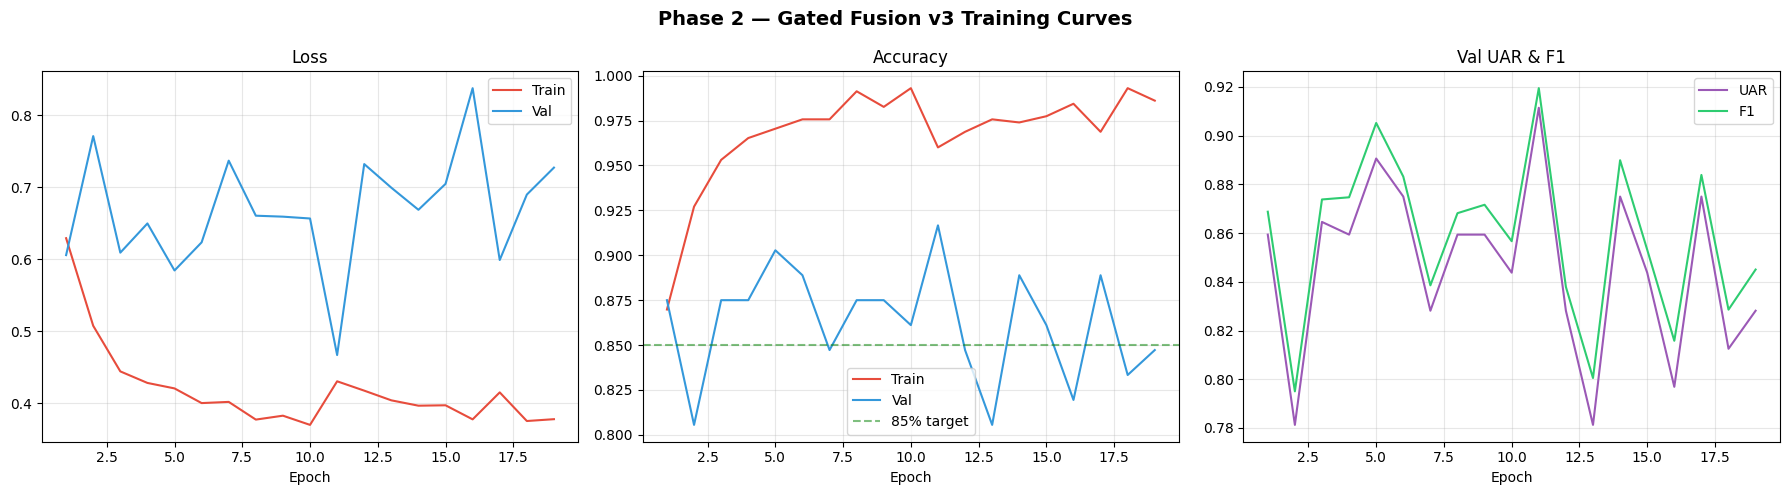

In [20]:
# Cell 18 — Training Curves  [UNCHANGED from v2]

epochs_ran = len(history["train_acc"])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(x, history["train_loss"], label="Train", color="#e74c3c")
axes[0].plot(x, history["val_loss"],   label="Val",   color="#3498db")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x, history["train_acc"], label="Train", color="#e74c3c")
axes[1].plot(x, history["val_acc"],   label="Val",   color="#3498db")
axes[1].axhline(0.85, color="green", ls="--", alpha=0.5, label="85% target")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(x, history["val_uar"], label="UAR", color="#9b59b6")
axes[2].plot(x, history["val_f1"],  label="F1",  color="#2ecc71")
axes[2].set_title("Val UAR & F1"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Phase 2 — Gated Fusion v3 Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()



FINAL TEST RESULTS
  Accuracy : 0.9398 (93.98%)
  UAR      : 0.9427
  Macro-F1 : 0.9410
              precision    recall  f1-score   support

       angry     0.9020    0.9583    0.9293        48
       happy     1.0000    1.0000    1.0000        48
     neutral     0.9429    0.9167    0.9296        72
         sad     0.9149    0.8958    0.9053        48

    accuracy                         0.9398       216
   macro avg     0.9399    0.9427    0.9410       216
weighted avg     0.9403    0.9398    0.9398       216

Unimodal baselines (pre-trained backbones):
  SER (audio-only) — Acc=0.8009  UAR=0.7951
  FER (visual-only)— Acc=0.7593  UAR=0.7743
  Gated Fusion v3  — Acc=0.9398    UAR=0.9427


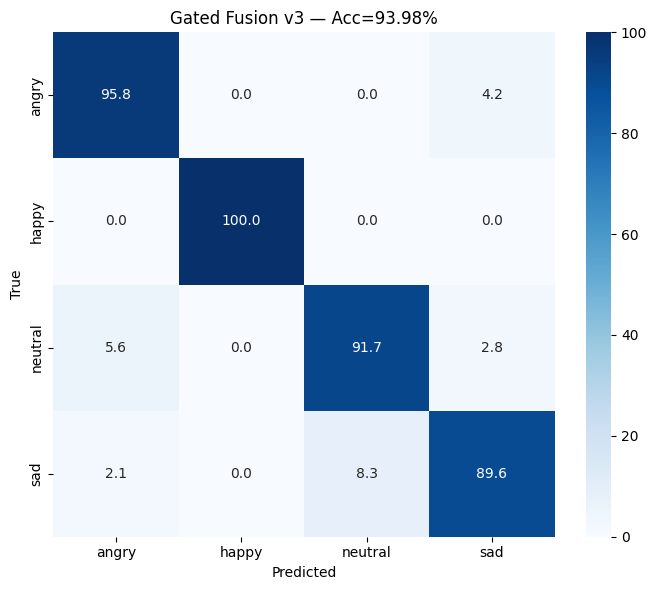

In [21]:
# Cell 19 — Final Evaluation & Confusion Matrix  [UNCHANGED from v2]

test_m = eval_mm(model, mm_test_loader, criterion)

print(f"\n{'='*60}")
print(f"FINAL TEST RESULTS")
print(f"  Accuracy : {test_m['acc']:.4f} ({test_m['acc']*100:.2f}%)")
print(f"  UAR      : {test_m['uar']:.4f}")
print(f"  Macro-F1 : {test_m['f1']:.4f}")
print(f"{'='*60}")
print(classification_report(test_m["labels"], test_m["preds"],
                             target_names=EMOTION_LABELS, digits=4))

print("Unimodal baselines (pre-trained backbones):")
print(f"  SER (audio-only) — Acc={test_ser['acc']:.4f}  UAR={test_ser['uar']:.4f}")
print(f"  FER (visual-only)— Acc={test_fer['acc']:.4f}  UAR={test_fer['uar']:.4f}")
print(f"  Gated Fusion v3  — Acc={test_m['acc']:.4f}    UAR={test_m['uar']:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
cm     = confusion_matrix(test_m["labels"], test_m["preds"])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=ax)
ax.set_title(f"Gated Fusion v3 — Acc={test_m['acc']:.2%}")
ax.set_ylabel("True"); ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()


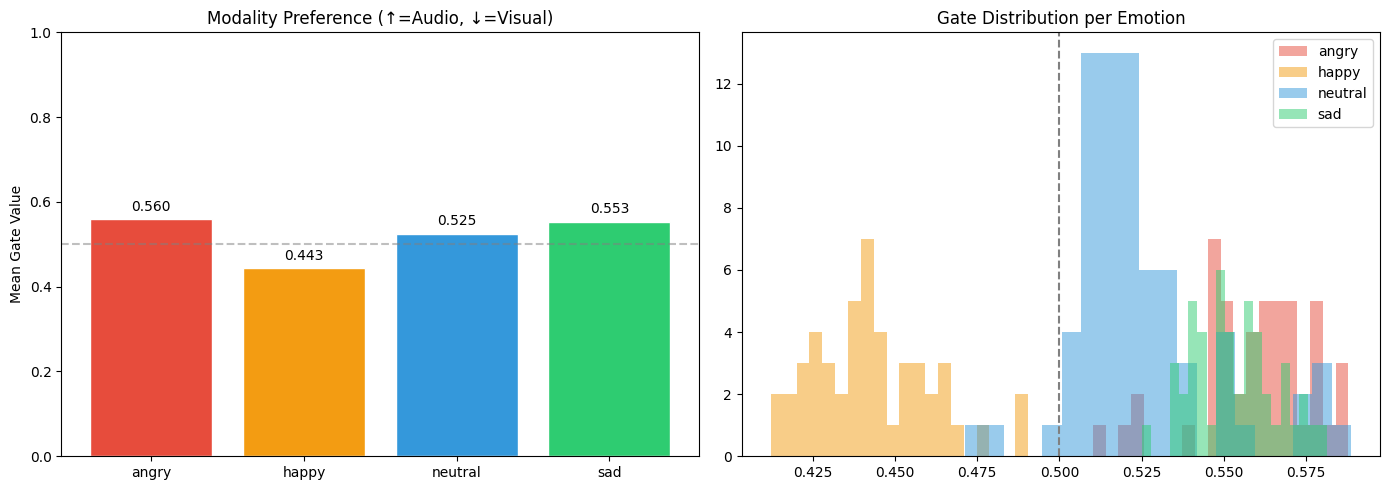


Gate value breakdown:
  angry     : mean=0.5595  std=0.0174  ↑ Audio
  happy     : mean=0.4434  std=0.0183  ↓ Visual
  neutral   : mean=0.5249  std=0.0217  ≈ Balanced
  sad       : mean=0.5529  std=0.0128  ↑ Audio

Interpretation (v3 expectation):
  With DINOv2 + Temporal Attention, gate values for visual-rich emotions
  (happy, sad) should shift toward ↓ Visual vs v2 where audio dominated.


In [22]:
# Cell 20 — Gate Analysis (which modality wins per emotion?)  [UNCHANGED from v2]

@torch.no_grad()
def get_gates(model, loader):
    model.eval()
    gates, lbls = [], []
    for wav, clip, labels in tqdm(loader, desc="Gate analysis", leave=False):
        _, g = model(wav.to(DEVICE), clip.to(DEVICE), return_gate=True)
        gates.append(g.cpu()); lbls.extend(labels.tolist())
    return torch.cat(gates), np.array(lbls)

gates, glabels = get_gates(model, mm_test_loader)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
means  = [gates[glabels == i].mean().item() for i in range(NUM_CLASSES)]

bars = axes[0].bar(EMOTION_LABELS, means, color=colors, edgecolor="white")
axes[0].axhline(0.5, color="gray", ls="--", alpha=0.5)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Mean Gate Value")
axes[0].set_title("Modality Preference (↑=Audio, ↓=Visual)")
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")

for i, em in enumerate(EMOTION_LABELS):
    g_avg = gates[glabels == i].mean(dim=-1).numpy()
    axes[1].hist(g_avg, bins=20, alpha=0.5, label=em, color=colors[i])
axes[1].axvline(0.5, color="gray", ls="--"); axes[1].legend()
axes[1].set_title("Gate Distribution per Emotion")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "gate_analysis.png"), dpi=150)
plt.show()

print("\nGate value breakdown:")
for i, em in enumerate(EMOTION_LABELS):
    g    = gates[glabels == i].mean(dim=-1)
    bias = "↑ Audio" if g.mean() > 0.55 else "↓ Visual" if g.mean() < 0.45 else "≈ Balanced"
    print(f"  {em:<10}: mean={g.mean():.4f}  std={g.std():.4f}  {bias}")

print("\nInterpretation (v3 expectation):")
print("  With DINOv2 + Temporal Attention, gate values for visual-rich emotions")
print("  (happy, sad) should shift toward ↓ Visual vs v2 where audio dominated.")


In [23]:
# Cell 21 — Save Final Package  [updated for v3 config]
import datetime

final_path = os.path.join(SAVE_DIR, "multimodal_final_v3.pt")
torch.save({
    "model_state": model.state_dict(),
    "config": {
        "version"       : "v3",
        "fusion_dim"    : FUSION_DIM,
        "n_classes"     : NUM_CLASSES,
        "dropout"       : DROPOUT,
        "emotion_labels": EMOTION_LABELS,
        "audio_dim"     : 768,
        "visual_dim"    : VISUAL_DIM,    # 768 (DINOv2 ViT-B)
        "num_frames"    : NUM_FRAMES,    # 16
        "img_size"      : IMG_SIZE,      # 224
        "fer_backbone"  : "vit_base_patch14_dinov2.lvd142m",
        "ser_backbone"  : "microsoft/wavlm-base-plus",
    },
    "results": {
        "ser_test_acc"   : float(test_ser["acc"]),
        "fer_test_acc"   : float(test_fer["acc"]),
        "fusion_test_acc": float(test_m["acc"]),
        "fusion_test_uar": float(test_m["uar"]),
        "fusion_test_f1" : float(test_m["f1"]),
    },
    "ser_ckpt" : best_ser_ckpt,
    "fer_ckpt" : best_fer_ckpt,
    "timestamp": datetime.datetime.now().isoformat(),
}, final_path)

print(f"Saved to: {final_path}")
print(f"\n{'='*60}")
print(f"  SER   (audio-only) : {test_ser['acc']*100:.2f}%")
print(f"  FER   (visual-only): {test_fer['acc']*100:.2f}%")
print(f"  Gated Fusion v3    : {test_m['acc']*100:.2f}%")
print(f"{'='*60}")
print(f"\n✅ All done! Checkpoint: {final_path}")


Saved to: /DATA/hackathon/multimodal_fusion_v3/multimodal_final_v3.pt

  SER   (audio-only) : 80.09%
  FER   (visual-only): 75.93%
  Gated Fusion v3    : 93.98%

✅ All done! Checkpoint: /DATA/hackathon/multimodal_fusion_v3/multimodal_final_v3.pt
